In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats

*************************************************************************
*                                                                       *
*                ███████████████████████████████████████                *
*                ▓  ▓▓▓▓  ▓▓  ▓▓▓▓  ▓▓        ▓▓       ▓                *
*                ▓   ▓▓   ▓▓  ▓▓▓▓  ▓▓▓▓▓  ▓▓▓▓▓  ▓▓▓▓▓▓                *
*                ▒        ▒▒  ▒▒▒▒  ▒▒▒▒▒  ▒▒▒▒▒       ▒                *
*                ▒  ▒  ▒  ▒▒  ▒▒▒▒  ▒▒▒▒▒  ▒▒▒▒▒  ▒▒▒▒▒▒                *
*                ░  ░░░░  ░░░░    ░░░░░░░  ░░░░░       ░                *
*                ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░                *
*                   https://github.com/wjwoodley/mute                   *
*                                                                       *
* Author:  William Woodley                                              *
* Version: 3.0.0                                                        *
*                                     

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '10' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def T(A):
    return np.swapaxes(A, -2, -1)

## Load Production Rates

In [4]:
Prop = Propagator(logE_mu_max=7.5)

C:\Users\walte\anaconda3\lib\site-packages\crflux\models.py:1068: DeprecationWarning: Please import `InterpolatedUnivariateSpline` from the `scipy.interpolate` namespace; the `scipy.interpolate.fitpack2` namespace is deprecated and will be removed in SciPy 2.0.0.
  self.p_frac_spl, self.p_flux_spl, self.n_flux_spl = pickle.load(
C:\Users\walte\anaconda3\lib\site-packages\crflux\models.py:1068: DeprecationWarning: Please import `InterpolatedUnivariateSpline` from the `scipy.interpolate` namespace; the `scipy.interpolate.fitpack2` namespace is deprecated and will be removed in SciPy 2.0.0.
  self.p_frac_spl, self.p_flux_spl, self.n_flux_spl = pickle.load(


In [5]:
df_Pfast = pd.read_csv('Production Rates/P_fast_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [6]:
for i,m in enumerate(model_names):
    print(i,m)

0 JN-fit_H-ice_alpha=0.63
1 GlobalSplineFitBeta_SIBYLL23CPP_alpha=0.63
2 HillasGaisser2012 H3a_SIBYLL23CPP_alpha=0.63
3 HillasGaisser2012 H4a_SIBYLL23CPP_alpha=0.63
4 GlobalSplineFitBeta_SIBYLL23C03_alpha=0.63
5 HillasGaisser2012 H3a_SIBYLL23C03_alpha=0.63
6 HillasGaisser2012 H4a_SIBYLL23C03_alpha=0.63
7 GlobalSplineFitBeta_SIBYLL-2.3c_alpha=0.63
8 HillasGaisser2012 H3a_SIBYLL-2.3c_alpha=0.63
9 HillasGaisser2012 H4a_SIBYLL-2.3c_alpha=0.63
10 GlobalSplineFitBeta_SIBYLL-2.3_alpha=0.63
11 HillasGaisser2012 H3a_SIBYLL-2.3_alpha=0.63
12 HillasGaisser2012 H4a_SIBYLL-2.3_alpha=0.63
13 GlobalSplineFitBeta_SIBYLL-2.1_alpha=0.63
14 HillasGaisser2012 H3a_SIBYLL-2.1_alpha=0.63
15 HillasGaisser2012 H4a_SIBYLL-2.1_alpha=0.63
16 GlobalSplineFitBeta_EPOS-LHC_alpha=0.63
17 HillasGaisser2012 H3a_EPOS-LHC_alpha=0.63
18 HillasGaisser2012 H4a_EPOS-LHC_alpha=0.63
19 GlobalSplineFitBeta_QGSJET-II-04_alpha=0.63
20 HillasGaisser2012 H3a_QGSJET-II-04_alpha=0.63
21 HillasGaisser2012 H4a_QGSJET-II-04_alpha=0.63
2

In [7]:
Prop.Phi['prod']=P_14C
C_flow = F.flow_14C(Prop)

100%|█████████████████████████████████████████████████████████████████████████████| 7283/7283 [01:01<00:00, 119.39it/s]


In [16]:
from mpmath import gammainc
from mpmath import mpc

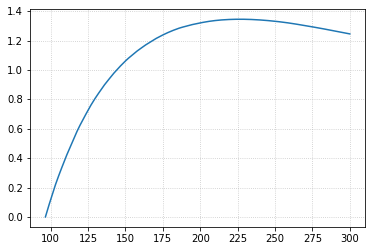

In [30]:
plt.plot(Prop.z[Prop.i_start:], np.exp(-Prop.lambd*Prop.t[Prop.i_start:])*abs(np.array(gammainc(-0.8,-Prop.lambd*Prop.t[Prop.i_start])) - np.array([gammainc(-0.8,-Prop.lambd*t_p) for t_p in Prop.t[Prop.i_start:]])))

In [22]:
from scipy.optimize import curve_fit

In [23]:
def power_law(x,A,B):
    # x = ice age [yrs]
    # A = scale factor
    # B = power index
    return np.exp(A)*(x/1e3)**B

In [28]:
def int_power_law(A,B):
    # A C^x int_(x0)^(x1) dx'
    x0 = Prop.t_bins[Prop.i_start+1:].reshape((-1,1))
    x1 = Prop.t[Prop.i_start:].reshape((1,-1))
    dx = Prop.dt[Prop.i_start:].reshape((1,-1))
    
    return (np.exp(A)*np.sum((1-Prop.lambd)**x0 * (x1/1e3)**B * (1-Prop.lambd)**(-x1) * dx * (x1<x0), axis=1))#@Prop.S_mat[Prop.i_start:]

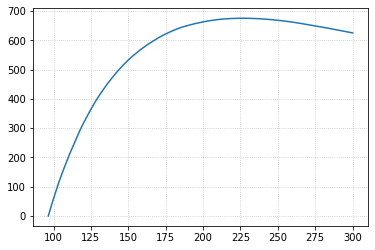

In [29]:
plt.plot(Prop.z[Prop.i_start:], int_power_law(1.,-1.8))

In [12]:
params = np.array([curve_fit(power_law, Prop.t[Prop.i_start:], p)[0] for p in tqdm(np.sum(P_14C,axis=1)[:,Prop.i_start:])])

100%|███████████████████████████████████████████████████████████████████████████████| 239/239 [00:01<00:00, 124.80it/s]


In [13]:
params_fast = np.array([curve_fit(power_law, Prop.t[Prop.i_start:], p)[0] for p in tqdm(P_14C[:,0,Prop.i_start:])])

100%|███████████████████████████████████████████████████████████████████████████████| 239/239 [00:01<00:00, 130.32it/s]


In [14]:
params_neg = np.array([curve_fit(power_law, Prop.t[Prop.i_start:], p)[0] for p in tqdm(P_14C[:,1,Prop.i_start:])])

100%|███████████████████████████████████████████████████████████████████████████████| 239/239 [00:02<00:00, 101.53it/s]


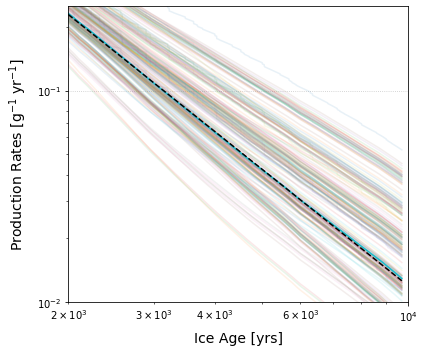

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
ax.plot(Prop.t, (P_14C[:,0].T + P_14C[:,1].T), alpha=0.1)
ax.plot(Prop.t, ((P_14C[:,0].T + P_14C[:,1].T))[:,210])
ax.plot(Prop.t, power_law(Prop.t,*params[210]), c='k', ls='--')
ax.set(yscale='log',
       xscale='log',
       xlabel='Ice Age [yrs]',
       ylabel=r'Production Rates [g$^{-1}$ yr$^{-1}$]',
       xlim=(2e3,1e4),
      ylim=(1e-2,0.25))
plt.show()

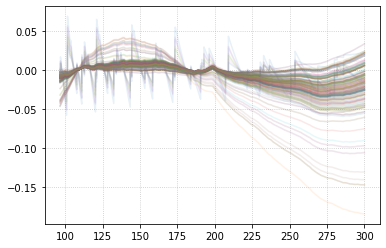

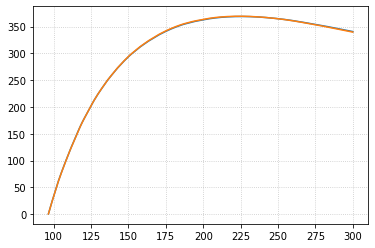

In [15]:
i=-1

#plt.plot(Prop.z[Prop.i_start:], np.sum(P_14C,axis=1)[i,Prop.i_start:])
for i,p in enumerate(params):
    plt.plot(Prop.z[Prop.i_start:], power_law(Prop.t[Prop.i_start:],*p)/np.sum(P_14C,axis=1)[i,Prop.i_start:]-1, alpha=0.1)
#plt.plot(Prop.z[Prop.i_start:], np.sum(P_14C,axis=1)[i,Prop.i_start:]/np.sum(P_14C,axis=1)[i,Prop.i_start:])
#plt.plot(Prop.z[Prop.i_start:], power_law(Prop.t[Prop.i_start:],*params[i])/np.sum(P_14C,axis=1)[i,Prop.i_start:])
plt.show()

plt.plot(Prop.z[Prop.i_start:], np.sum(C_flow,axis=1)[i])
plt.plot(Prop.z[Prop.i_start:], int_power_law(*params[i]))
#plt.plot(Prop.z[Prop.i_start:], np.sum(C_flow,axis=1)[i]/np.sum(C_flow,axis=1)[i])
#plt.plot(Prop.z[Prop.i_start:], int_power_law(*params[i])/np.sum(C_flow,axis=1)[i])
plt.show()

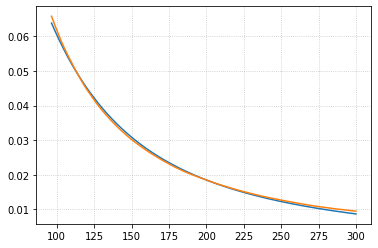

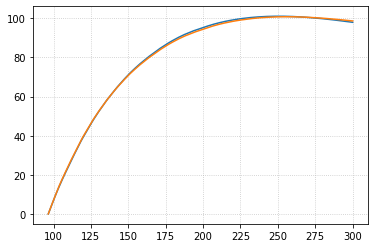

In [16]:
i=0

plt.plot(Prop.z[Prop.i_start:], P_14C[i,0,Prop.i_start:])
plt.plot(Prop.z[Prop.i_start:], power_law(Prop.t[Prop.i_start:],*params_fast[i]))
#plt.plot(Prop.z[Prop.i_start:], np.sum(P_14C,axis=1)[i,Prop.i_start:]/np.sum(P_14C,axis=1)[i,Prop.i_start:])
#plt.plot(Prop.z[Prop.i_start:], power_law(Prop.t[Prop.i_start:],*params[i])/np.sum(P_14C,axis=1)[i,Prop.i_start:])
plt.show()

plt.plot(Prop.z[Prop.i_start:], C_flow[i,0])
plt.plot(Prop.z[Prop.i_start:], int_power_law(*params_fast[i]))
#plt.plot(Prop.z[Prop.i_start:], np.sum(C_flow,axis=1)[i]/np.sum(C_flow,axis=1)[i])
#plt.plot(Prop.z[Prop.i_start:], int_power_law(*params[i])/np.sum(C_flow,axis=1)[i])
plt.show()

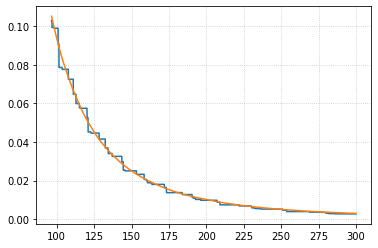

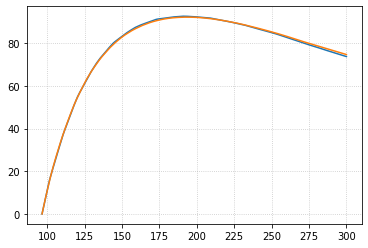

In [17]:
i=0

plt.plot(Prop.z[Prop.i_start:], P_14C[i,1,Prop.i_start:])
plt.plot(Prop.z[Prop.i_start:], power_law(Prop.t[Prop.i_start:],*params_neg[i]))
#plt.plot(Prop.z[Prop.i_start:], np.sum(P_14C,axis=1)[i,Prop.i_start:]/np.sum(P_14C,axis=1)[i,Prop.i_start:])
#plt.plot(Prop.z[Prop.i_start:], power_law(Prop.t[Prop.i_start:],*params[i])/np.sum(P_14C,axis=1)[i,Prop.i_start:])
plt.show()

plt.plot(Prop.z[Prop.i_start:], C_flow[i,1])
plt.plot(Prop.z[Prop.i_start:], int_power_law(*params_neg[i]))
#plt.plot(Prop.z[Prop.i_start:], np.sum(C_flow,axis=1)[i]/np.sum(C_flow,axis=1)[i])
#plt.plot(Prop.z[Prop.i_start:], int_power_law(*params[i])/np.sum(C_flow,axis=1)[i])
plt.show()

## Statistics

In [36]:
f_2sigma = True # Use the 2-sigma hull values of the f-factors (False uses older chi^2 measurement)
Normalize = False # Normalize all production models to Heisinger
error = 0.02 # relative systematic error of 14CO samples

In [37]:
if f_2sigma:
    df = pd.read_csv('factors_2sigma_hull.csv', header=None)
    f_factors = np.array([df[1],df[0]]).T
    f_weights = np.ones(len(f_factors))
else:
    df = pd.read_csv('14CO_f_all_ChiSq.csv')
    f_factors = np.array([df['fast'],df['f_neg']]).T[1:]
    f_weights = np.array(np.exp(-df['Chi_sq']/2))[1:] # convert chi^2 to prior weight

C_pred_0 = C_flow @ Prop.S_mat[Prop.i_start:]
# axis0 - Production Model
# axis1 - Production Mode (fast, neg)
# axis2 - Sample Depth

C_weights = np.ones(len(C_pred_0))

if Normalize:
    C_norm = np.sum(C_flow * Prop.dh[Prop.i_start:], axis=-1)
    
    C_pred_0 = C_pred_0 / np.reshape(C_norm, (-1,2,1)) * C_norm[-1].reshape(1,-1,1)

In [38]:
C_0 = np.average(C_pred_0, weights=C_weights, axis=0, keepdims=True)
# axis0 - Production Model
# axis1 - Production Mode (fast, neg)
# axis2 - Sample Depth

C_0_cov = np.moveaxis(np.reshape(
    np.cov(np.reshape(C_pred_0, (len(C_pred_0), -1)), rowvar=False, aweights=C_weights),
    (*np.shape(C_0), *np.shape(C_0)[1:])), (1,3), (-2,-1))
# axis0 - Production Model
# axis1 - Sample Depth A
# axis2 - Sample Depth B
# axis3 - Production Mode A
# axis4 - Production Mode B
    
C_w = np.ones(1)

f_avg = np.average(f_factors, weights=f_weights, axis=0)
# axis0 - Production Mode

f = np.average(f_factors, weights=f_weights, axis=0, keepdims=True)
# axis0 - f-factors
# axis1 - Production Mode

f_cov = np.reshape(np.cov(f_factors, rowvar=False, aweights=f_weights), (1,2,2))
# axis0 - f-factors
# axis1 - Production Mode A
# axis2 - Production Mode B

f_w = np.ones(1)

CO_0 = f @ C_0
# axis0 - Production Model
# axis1 - f-factors
# axis2 - Sample Depth

CO_0_cov = (np.reshape(f,(1,len(f),1,1,1,-1)) @ np.reshape(C_0_cov, (len(C_0),1,*np.shape(C_0_cov)[1:])) @ np.reshape(f,(1,len(f),1,1,-1,1)))[:,:,:,:,0,0] + T(np.reshape(C_0, (len(C_0),1,2,-1))) @ np.reshape(f_cov, (1,len(f),2,2)) @ np.reshape(C_0, (len(C_0),1,2,-1)) + np.sum(np.reshape(C_0_cov, (len(C_0),1,*np.shape(C_0_cov)[1:])) * np.reshape(f_cov, (1,len(f),1,1,2,2)), axis=(-2,-1))
# axis0 - Production Model
# axis1 - f-factors
# axis2 - Sample Depth A
# axis3 - Sample Depth B

rel_err = error * np.ones(np.shape(CO_0)[-1])
# axis0 - Sample Depth

s_cov = np.diag(rel_err**2)
# axis0 - Sample Depth A
# axis1 - Sample Depth B

Sigma_0 = CO_0_cov * np.reshape(1+s_cov, (1,1,*np.shape(s_cov))) + np.reshape(CO_0, (*np.shape(CO_0),1)) * np.reshape(CO_0, (*np.shape(CO_0)[:-1],1,-1)) * np.reshape(s_cov, (1,1,*np.shape(s_cov)))
Sigma_0 = np.expand_dims(Sigma_0, axis=0)
# axis0 - NONE
# axis1 - Production Model
# axis2 - f-factors
# axis3 - Sample Depth A
# axis4 - Sample Depth B

Sigma_0_inv = np.linalg.inv(Sigma_0)

## Plots

In [55]:
params = np.array([curve_fit(power_law, Prop.t[Prop.i_start:], p)[0] for p in tqdm((f_avg @ P_14C)[:,Prop.i_start:])])

100%|███████████████████████████████████████████████████████████████████████████████| 239/239 [00:01<00:00, 129.78it/s]


In [41]:
params_f = np.array([[curve_fit(power_law, Prop.t[Prop.i_start:], p)[0] for p in prod] for prod in tqdm((f_factors @ P_14C)[:,:,Prop.i_start:])])

100%|████████████████████████████████████████████████████████████████████████████████| 239/239 [03:55<00:00,  1.01it/s]


In [59]:
p_all = params[:-1].reshape((7,-1,2))[:,1:].reshape(7,-1,3,2).swapaxes(0,2)

In [57]:
P_all = (f_avg @ P_14C)[:-1].reshape((7,-1,np.shape(P_14C)[-1]))[:,1:].reshape(7,11,3,-1).swapaxes(0,2)

In [42]:
p_all_f = params_f[:-1].reshape((7,-1,len(f_factors),2))[:,1:].reshape(7,-1,3,len(f_factors),2).swapaxes(0,2)

In [43]:
P_all_f = (f_factors @ P_14C)[:-1].reshape((7,-1,len(f_factors),np.shape(P_14C)[-1]))[:,1:].reshape(7,11,3,len(f_factors),-1).swapaxes(0,2)

In [99]:
CO_all_f = (f_factors @ C_pred_0)[:-1].reshape((7,-1,len(f_factors),10))[:,1:].reshape(7,11,3,len(f_factors),10).swapaxes(0,2)

In [100]:
CO_all = (f_avg @ C_pred_0)[:-1].reshape((7,-1,10))[:,1:].reshape(7,11,3,10).swapaxes(0,2)

In [101]:
m_names = np.array(model_names)[:-1].reshape((7,-1))[:,1:].reshape(7,11,3).swapaxes(0,2)

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.36it/s]


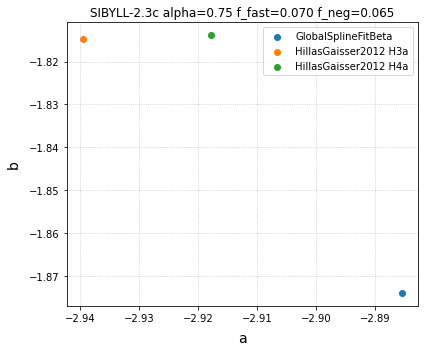

a = -2.91 +/- 0.02
b = -1.83 +/- 0.03


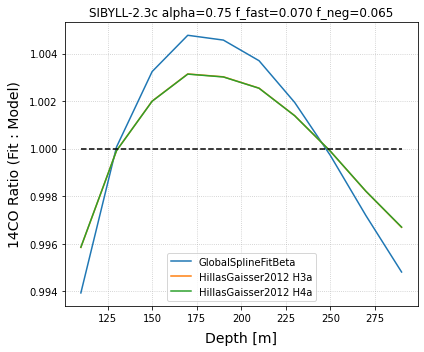

Average RMS error: 0.3%


In [118]:
p_cut = p_all[:,2,-1]
names_cut = m_names[:,2,-1]
CO_cut = CO_all[:,2,-1]

co_cut = np.array([int_power_law(*p) for p in tqdm(p_cut)])

fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
for i,p in enumerate(p_cut):
    ax.scatter(p[0],p[1], label=names_cut[i].split('_')[0])
ax.legend()
ax.set(
    xlabel='a',
    ylabel='b',
    title='{1} {2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)
plt.show()

print(r'a = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=0)[0], np.std(p_cut, axis=0)[0]))
print(r'b = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=0)[1], np.std(p_cut, axis=0)[1]))


fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
for i,c in enumerate(co_cut):
    ax.plot(Prop.z_samp, c/CO_cut[i], label=names_cut[i].split('_')[0])
ax.plot(Prop.z_samp, Prop.z_samp*0+1, ls='--', c='k')
ax.legend()
ax.set(
    xlabel='Depth [m]',
    ylabel='14CO Ratio (Fit : Model)',
    title='{1} {2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)
plt.show()

print('Average RMS error: {:.1f}%'.format(np.mean(np.sqrt(np.mean((co_cut/CO_cut-1)**2, axis=-1)))*100.))

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.33it/s]


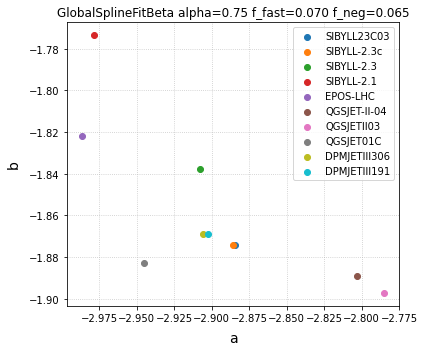

a = -2.90 +/- 0.06
b = -1.86 +/- 0.04


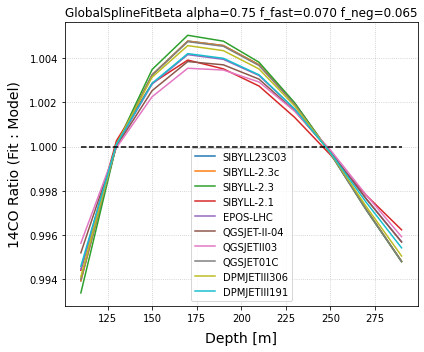

Average RMS error: 0.3%


In [119]:
p_cut = p_all[0,1:,-1]
names_cut = m_names[0,1:,-1]
CO_cut = CO_all[0,1:,-1]

co_cut = np.array([int_power_law(*p) for p in tqdm(p_cut)])

fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
for i,p in enumerate(p_cut):
    ax.scatter(p[0],p[1], label=names_cut[i].split('_')[1])
ax.legend()
ax.set(
    xlabel='a',
    ylabel='b',
    title='{0} {2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)
plt.show()

print(r'a = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=0)[0], np.std(p_cut, axis=0)[0]))
print(r'b = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=0)[1], np.std(p_cut, axis=0)[1]))


fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
for i,c in enumerate(co_cut):
    ax.plot(Prop.z_samp, c/CO_cut[i], label=names_cut[i].split('_')[1])
ax.plot(Prop.z_samp, Prop.z_samp*0+1, ls='--', c='k')
ax.legend()
ax.set(
    xlabel='Depth [m]',
    ylabel='14CO Ratio (Fit : Model)',
    title='{0} {2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)
plt.show()

print('Average RMS error: {:.1f}%'.format(np.mean(np.sqrt(np.mean((co_cut/CO_cut-1)**2, axis=-1)))*100.))

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:22<00:00,  7.54s/it]


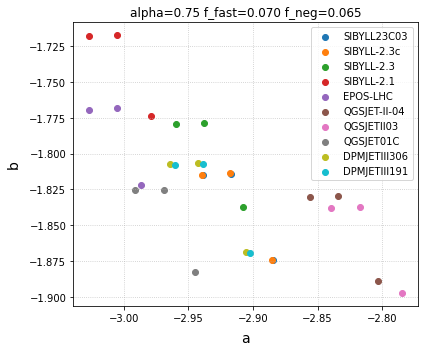

a = -2.93 +/- 0.06
b = -1.82 +/- 0.04


C:\Users\walte\AppData\Local\Temp/ipykernel_14100/4205582577.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


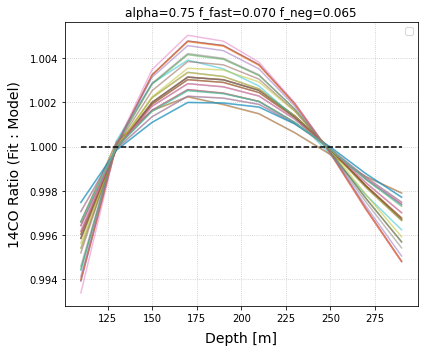

Average RMS error: 0.3%


In [120]:
p_cut = p_all[:,1:,-1]
names_cut = m_names[:,1:,-1]
CO_cut = CO_all[:,1:,-1]

co_cut = np.array([[int_power_law(*p) for p in par] for par in tqdm(p_cut)])

fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
for i,p in enumerate(p_cut.swapaxes(0,1)):
    ax.scatter(p[:,0],p[:,1], label=names_cut[0,i].split('_')[1])
ax.legend()
ax.set(
    xlabel='a',
    ylabel='b',
    title='{2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0,0].split('_'), *f_avg)
)
plt.show()

print(r'a = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=(0,1))[0], np.std(p_cut, axis=(0,1))[0]))
print(r'b = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=(0,1))[1], np.std(p_cut, axis=(0,1))[1]))


fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
ax.plot(Prop.z_samp, ((co_cut/CO_cut).T).reshape((len(Prop.z_samp),-1)), alpha=0.5)
ax.plot(Prop.z_samp, Prop.z_samp*0+1, ls='--', c='k')
ax.legend()
ax.set(
    xlabel='Depth [m]',
    ylabel='14CO Ratio (Fit : Model)',
    title='{2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0,0].split('_'), *f_avg)
)
plt.show()

print('Average RMS error: {:.1f}%'.format(np.mean(np.sqrt(np.mean((co_cut/CO_cut-1)**2, axis=-1)))*100.))

100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:03<00:00,  1.87it/s]


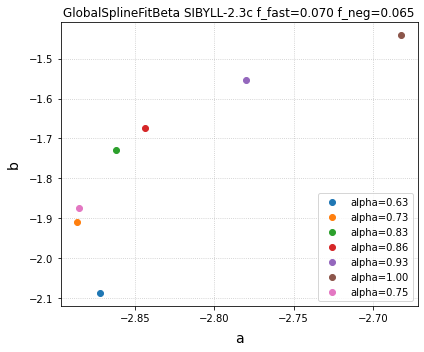

a = -2.83 +/- 0.07
b = -1.75 +/- 0.21


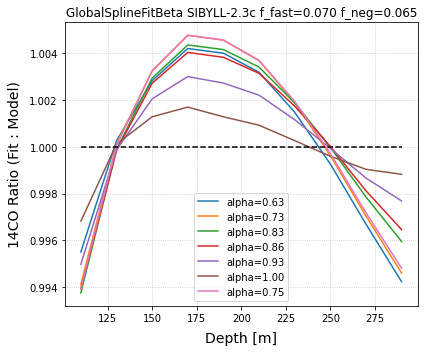

Average RMS error: 0.3%


In [121]:
p_cut = p_all[0,2,:]
names_cut = m_names[0,2,:]
CO_cut = CO_all[0,2,:]

co_cut = np.array([int_power_law(*p) for p in tqdm(p_cut)])

fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
for i,p in enumerate(p_cut):
    ax.scatter(p[0],p[1], label=names_cut[i].split('_')[2])
ax.legend()
ax.set(
    xlabel='a',
    ylabel='b',
    title='{0} {1} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)
plt.show()

print(r'a = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=0)[0], np.std(p_cut, axis=0)[0]))
print(r'b = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=0)[1], np.std(p_cut, axis=0)[1]))


fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
for i,c in enumerate(co_cut):
    ax.plot(Prop.z_samp, c/CO_cut[i], label=names_cut[i].split('_')[2])
ax.plot(Prop.z_samp, Prop.z_samp*0+1, ls='--', c='k')
ax.legend()
ax.set(
    xlabel='Depth [m]',
    ylabel='14CO Ratio (Fit : Model)',
    title='{0} {1} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)
plt.show()

print('Average RMS error: {:.1f}%'.format(np.mean(np.sqrt(np.mean((co_cut/CO_cut-1)**2, axis=-1)))*100.))

100%|████████████████████████████████████████████████████████████████████████████████| 118/118 [01:05<00:00,  1.81it/s]


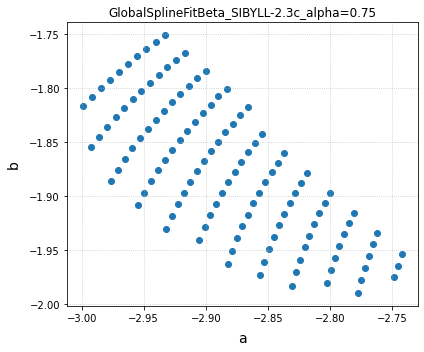

C:\Users\walte\AppData\Local\Temp/ipykernel_14100/3221481288.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


a = -2.88 +/- 0.06
b = -1.88 +/- 0.06


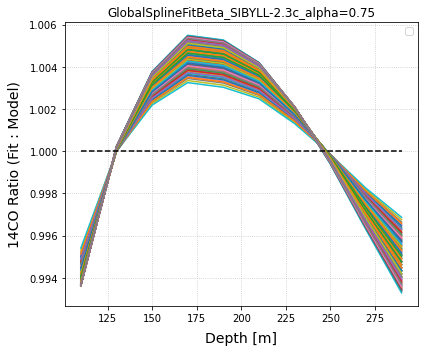

Average RMS error: 0.4%


In [122]:
p_cut = p_all_f[0,2,-1,:]
names_cut = m_names[0,2,-1]
CO_cut = CO_all_f[0,2,-1,:]

co_cut = np.array([int_power_law(*p) for p in tqdm(p_cut)])

fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
ax.scatter(p_cut[:,0],p_cut[:,1])
#ax.legend()
ax.set(
    xlabel='a',
    ylabel='b',
    title=names_cut
)
plt.show()

print(r'a = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=0)[0], np.std(p_cut, axis=0)[0]))
print(r'b = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=0)[1], np.std(p_cut, axis=0)[1]))


fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
for i,c in enumerate(co_cut):
    ax.plot(Prop.z_samp, c/CO_cut[i])
ax.plot(Prop.z_samp, Prop.z_samp*0+1, ls='--', c='k')
ax.legend()
ax.set(
    xlabel='Depth [m]',
    ylabel='14CO Ratio (Fit : Model)',
    title=names_cut
)
plt.show()

print('Average RMS error: {:.1f}%'.format(np.mean(np.sqrt(np.mean((co_cut/CO_cut-1)**2, axis=-1)))*100.))

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [11:04<00:00, 66.46s/it]


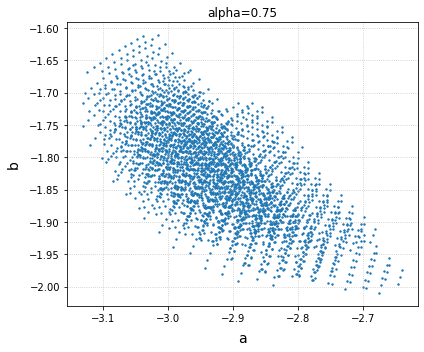

a = -2.92 +/- 0.09
b = -1.82 +/- 0.07


C:\Users\walte\AppData\Local\Temp/ipykernel_14100/4068669725.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


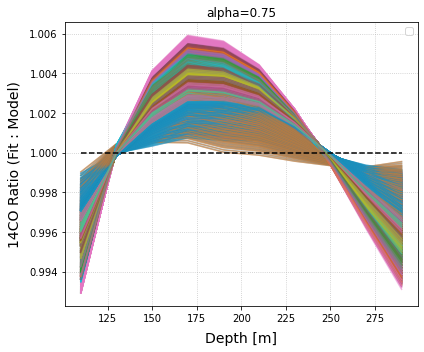

Average RMS error: 0.3%


In [123]:
p_cut = p_all_f[:,1:,-1,:]
CO_cut = CO_all_f[:,1:,-1,:]

co_cut = np.array([[[int_power_law(*p) for p in pa] for pa in tqdm(par)] for par in p_cut])

fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
ax.scatter(p_cut[:,:,:,0],p_cut[:,:,:,1], s=2)
#ax.legend()
ax.set(
    xlabel='a',
    ylabel='b',
    title=m_names[0,2,-1].split('_')[2]
)
plt.show()

print(r'a = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=(0,1,2))[0], np.std(p_cut, axis=(0,1,2))[0]))
print(r'b = {:.2f} +/- {:.2f}'.format(np.mean(p_cut, axis=(0,1,2))[1], np.std(p_cut, axis=(0,1,2))[1]))


fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
ax.plot(Prop.z_samp, ((co_cut/CO_cut).T).reshape((len(Prop.z_samp),-1)), alpha=0.5)
ax.plot(Prop.z_samp, Prop.z_samp*0+1, ls='--', c='k')
ax.legend()
ax.set(
    xlabel='Depth [m]',
    ylabel='14CO Ratio (Fit : Model)',
    title=m_names[0,2,-1].split('_')[2]
)
plt.show()

print('Average RMS error: {:.1f}%'.format(np.mean(np.sqrt(np.mean((co_cut/CO_cut-1)**2, axis=-1)))*100.))

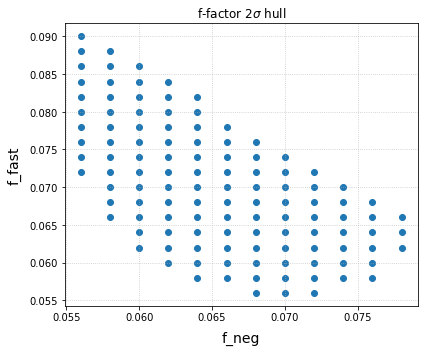

In [96]:
fig, ax = plt.subplots(1, 1, figsize=(6,5), tight_layout=True)
ax.scatter(f_factors[:,1], f_factors[:,0])
ax.set(
    xlabel='f_neg',
    ylabel='f_fast',
    title=r'f-factor 2$\sigma$ hull'
)
plt.show()